In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
try:
    df = pd.read_csv('L2.csv')
except Exception as e:
    print(f'Unknown Exception : \n{e}')

In [3]:
def mapping_function():
    df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes':1,'No':0})
mapping_function()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [5]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [6]:
# Now lets first analyze the correlation between the columns for collinearity

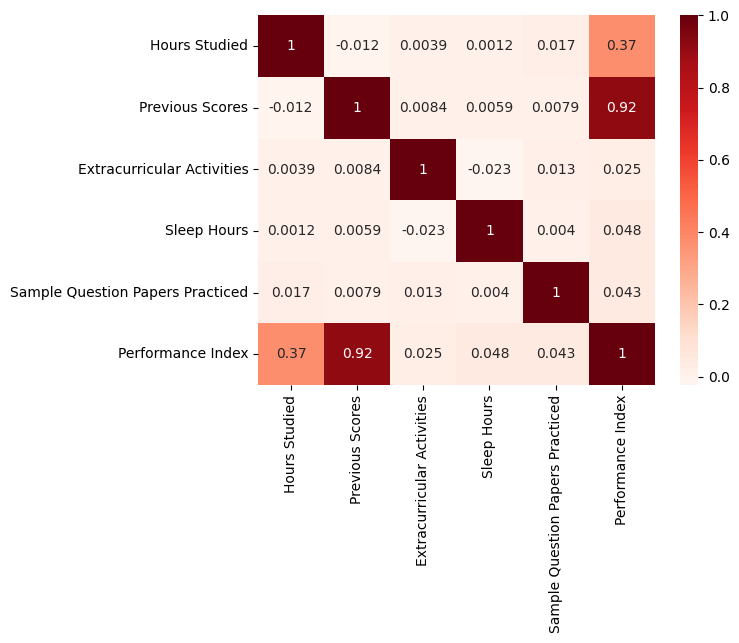

In [7]:
sns.heatmap(
                data = df.corr(),
                annot = True,
                cmap='Reds'
)
plt.show()
# No multicollinearity found and also found that performance index is having a high correlation with Previous Scores

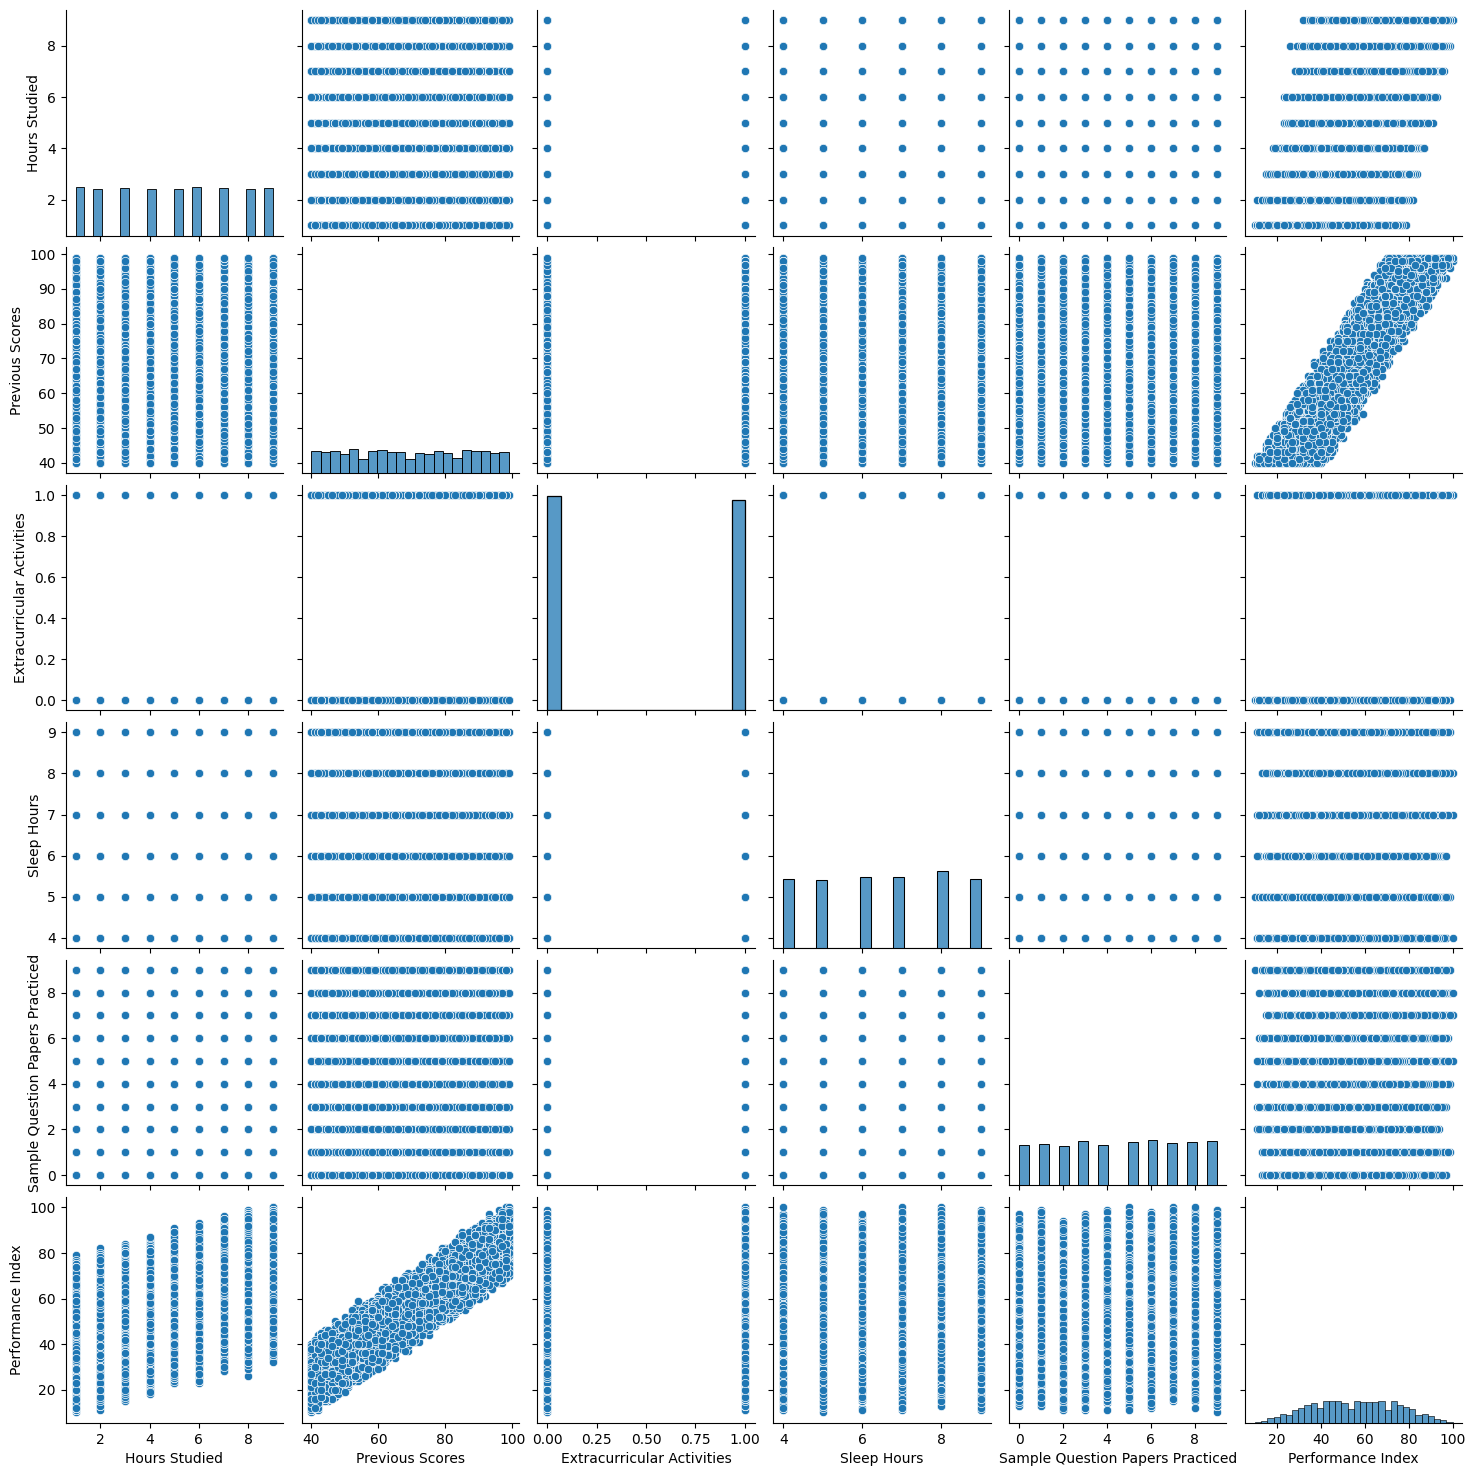

In [8]:
sns.pairplot(
                data = df
)
plt.show()

In [9]:
# Now we will try to get more insights on data columns

In [10]:
df.nunique() # To get an idea of the unique columns and using which I will select plots for the columns each

Hours Studied                        9
Previous Scores                     60
Extracurricular Activities           2
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64

In [11]:
# Univariate Analysis

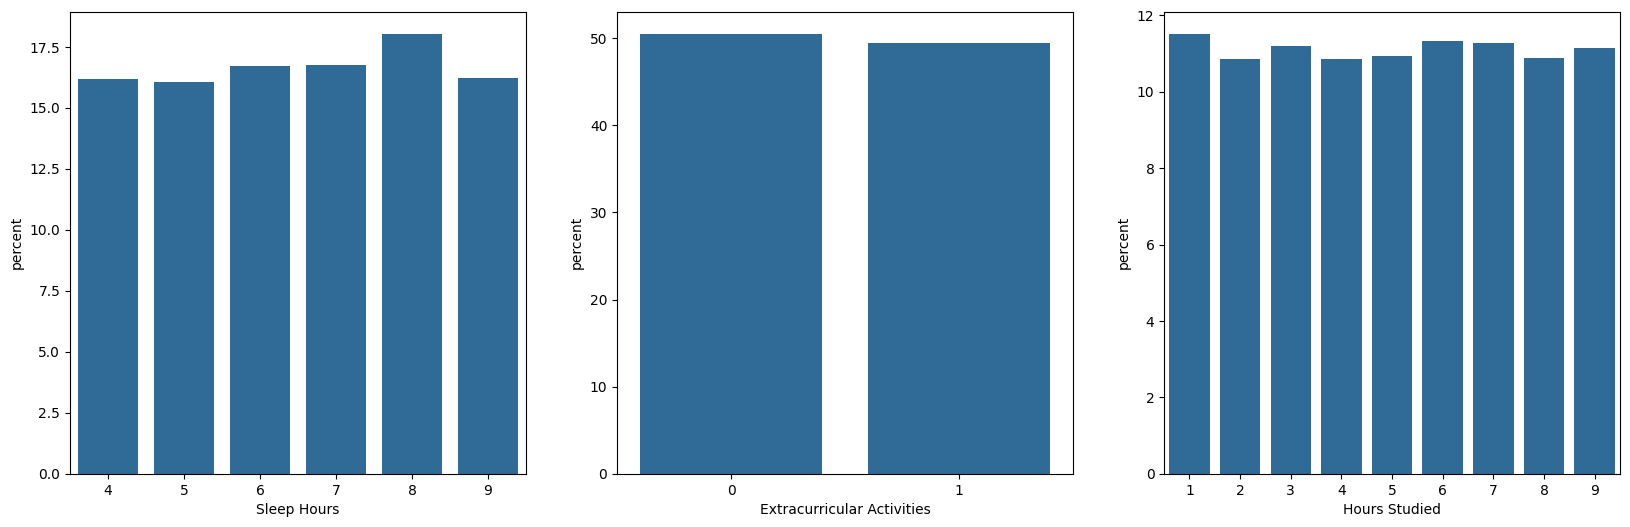

In [12]:
plt.figure(figsize=(20,6))
plt.subplot(131)
sns.countplot(data=df,x='Sleep Hours',stat='percent',color="#1F6CA7")
plt.subplot(132)
sns.countplot(data=df,x='Extracurricular Activities',stat='percent',color="#1F6CA7")
plt.subplot(133)
sns.countplot(data=df,x='Hours Studied',stat='percent',color="#1F6CA7")
plt.show()

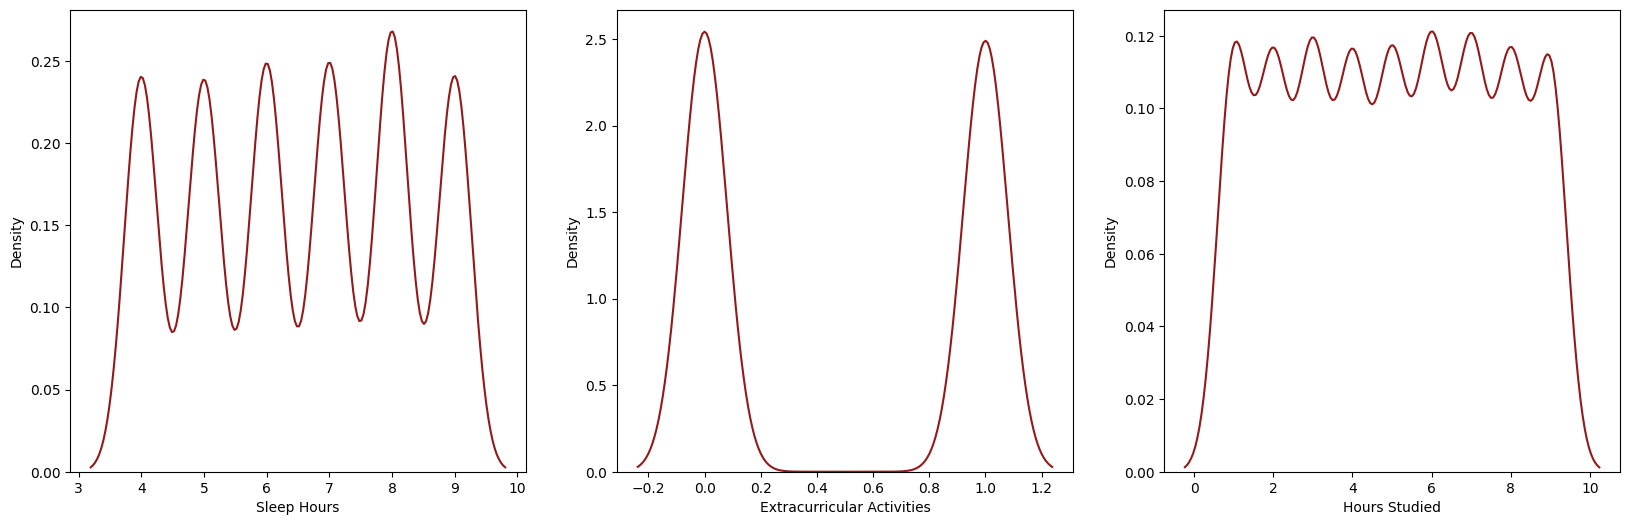

In [13]:
plt.figure(figsize=(20,6))
plt.subplot(131)
sns.kdeplot(data=df,x='Sleep Hours',color="#921A1A")
plt.subplot(132)
sns.kdeplot(data=df,x='Extracurricular Activities',color="#921A1A")
plt.subplot(133)
sns.kdeplot(data=df,x='Hours Studied',color="#921A1A")
plt.show()

In [14]:
# Bivariate Analysis

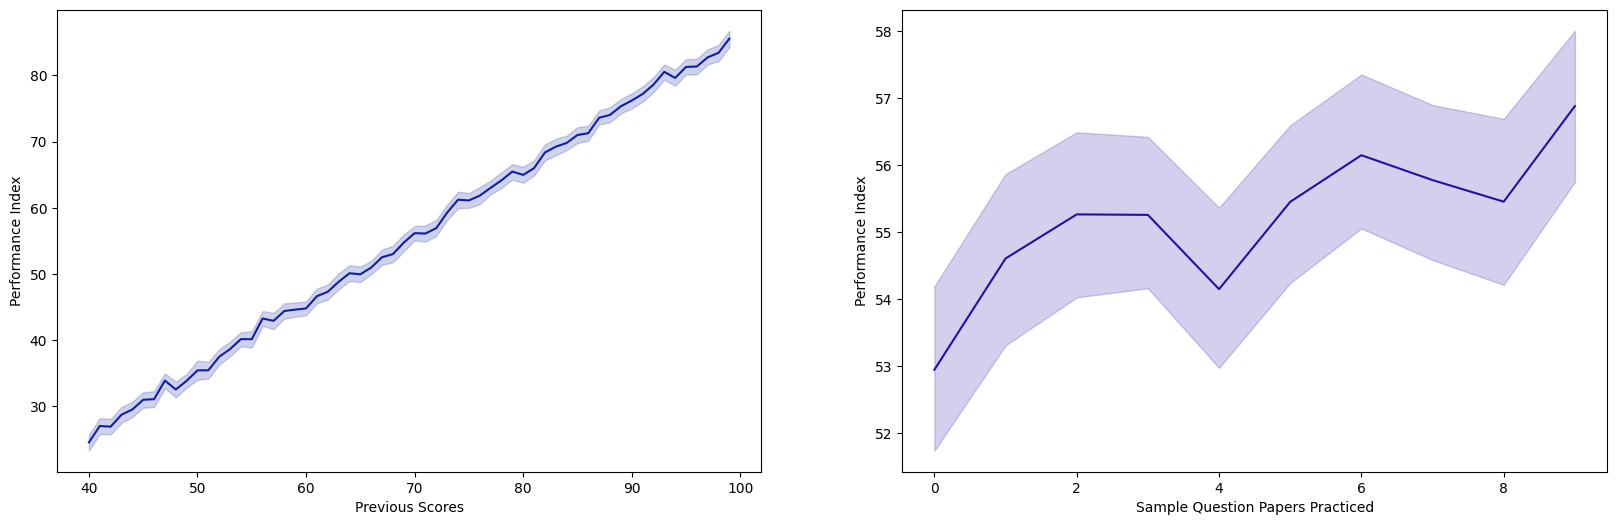

In [15]:
plt.figure(figsize=(20,6))
plt.subplot(121)
sns.lineplot(data=df,x='Previous Scores',y='Performance Index',color="#0F1EA8")
plt.subplot(122)
sns.lineplot(data=df,x='Sample Question Papers Practiced',y='Performance Index',color="#260FA8")
plt.show()

In [16]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [17]:
# Now splitting datasets

In [18]:
X , y  = df.drop(columns=['Performance Index']) , df['Performance Index']

In [19]:
# Train test split
from sklearn.model_selection import train_test_split

In [20]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
# Applying Scaling to reduce distance and center around 0

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [23]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [24]:
X_train_scalled = scaler.transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [25]:
X_train.iloc[0].values,X_train_scalled[0]

(array([ 4, 99,  1,  6,  1]),
 array([-0.37921729,  1.69543433,  1.01962103, -0.31944271, -1.26226064]))

In [26]:
# Now proceeding to model training

In [27]:
# Model Training

In [28]:
# First MODEL : Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
lr = LinearRegression()

In [87]:
lr.fit(X_train_scalled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
y_pred = lr.predict(X_test_scalled)

In [100]:
lr.coef_

array([ 7.42276987, 17.60827303,  0.29080153,  0.8138699 ,  0.54598268])

In [89]:
# Calcuating residuals

In [90]:
residuals = y_pred - y_test

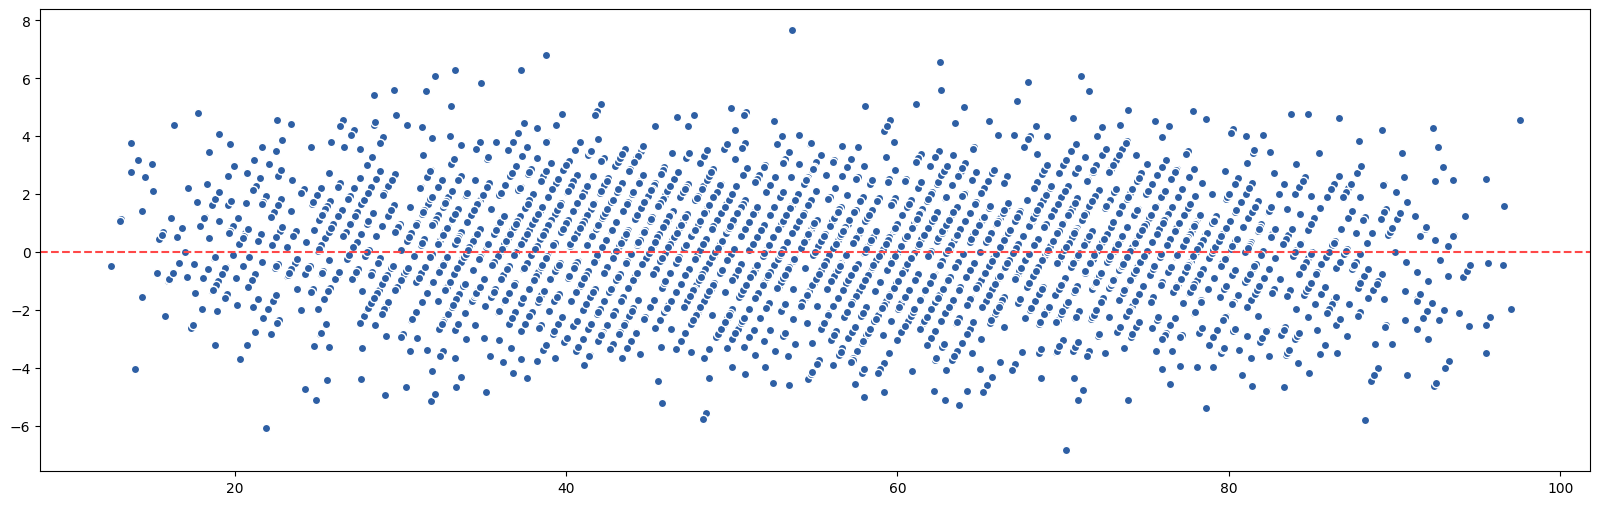

In [92]:
plt.figure(figsize=(20,6))
plt.axhline(y=0, color="#FF4848", linestyle='--')
plt.scatter(
            y_pred,
            residuals,
            color = "#2E5FA4",
            edgecolors='white'
)
plt.show()
# Random 

In [93]:
import scipy.stats as stats

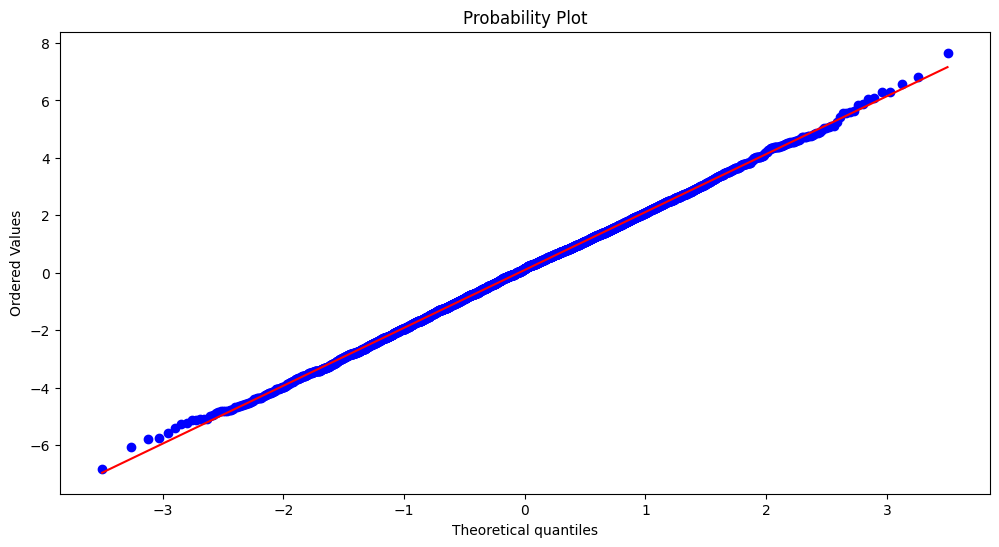

In [94]:
plt.figure(figsize=(12,6))
stats.probplot(residuals,dist='norm',plot=plt)
plt.show()

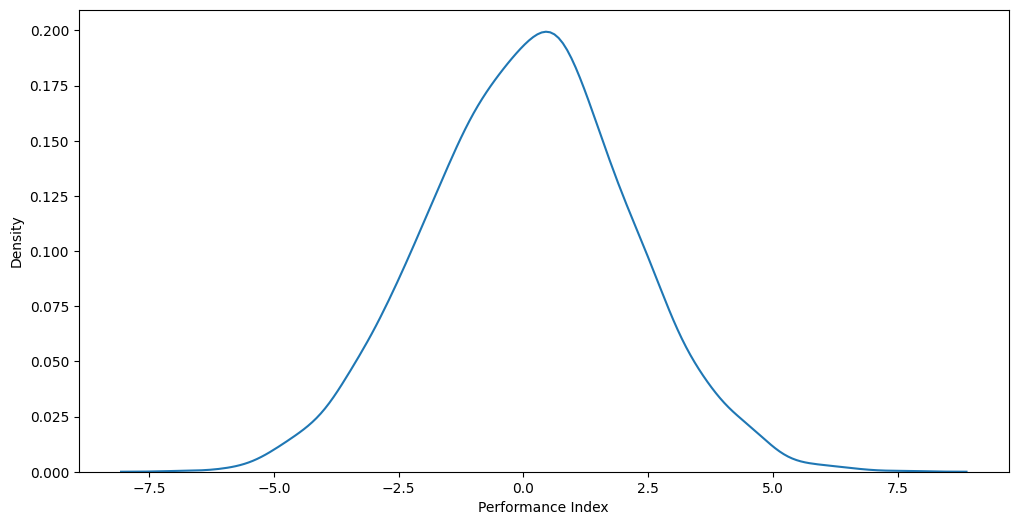

In [102]:
plt.figure(figsize=(12,6))
sns.kdeplot(residuals)
plt.show() 
# The residual graph is normal too.

In [95]:
# We can clearly see there is almost no tailedness

In [103]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error

In [97]:
r2_score(y_test,y_pred)

0.9890110607021136

In [98]:
root_mean_squared_error(y_test,y_pred)

2.016572295776346

In [104]:
mean_squared_error(y_test,y_pred)

4.066563824092683

In [105]:
# A very High prediction

In [106]:
# Now lets do cross val score

In [107]:
from sklearn.model_selection import cross_val_score

In [108]:
X_scalled = scaler.transform(X)

In [114]:
cvs = cross_val_score(  
                        lr,
                        X_scalled,
                        y,
                        cv = 5
)

In [115]:
cvs.mean()

np.float64(0.9887338678935833)

In [116]:
cvs.std()

np.float64(0.0003573764894568343)